In [1]:
# let's load in all our data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

adc_blank = 2879.0
od_init = 0.11
dil_fact = 10000
vol_on_plt = 0.1 # mL
cell_cult_vol = 3 # mL

filename = "data/ex_pt_1.csv"
data = pd.read_csv(filename, header=0, usecols=[0, 1])
data.rename(columns={
    "Time (s)": "time",
    "ADC (t)": "adc"
},
inplace=True)

print(data.head())
print(data.columns)

def adc_to_od(voltage, v_0):
    return -1 * np.log10(voltage/v_0)


data["od_val"] = adc_to_od(data["adc"], adc_blank)

print(data.head())

     time       adc
0     0.0  2239.415
1   360.0  2238.362
2   720.0  2237.310
3  1080.0  2236.258
4  1440.0  2235.206
Index(['time', 'adc'], dtype='object')
     time       adc    od_val
0     0.0  2239.415  0.109107
1   360.0  2238.362  0.109311
2   720.0  2237.310  0.109516
3  1080.0  2236.258  0.109720
4  1440.0  2235.206  0.109924


In [2]:
# let's prepare our data and convert to numpy

x = data["time"].to_numpy()
y = np.log(data["od_val"].to_numpy())
mask = (x > 8000) & (x < 50000)
x = x[mask]
y = y[mask]

In [3]:
# let's find the best region for linearity...

def region_score(x_start, x_stop, xs, ys):
    # mask xs and ys
    mask = (xs >= x_start) & (xs <= x_stop)
    xs = xs[mask]
    ys = ys[mask]

    # find best fit line for data in this range
    m, b = np.polyfit(xs, ys, 1)
    ys_pred = m * xs + b

    # calculate r^2 value
    r2 = r2_score(ys, ys_pred)

    # use our scoring formula -> region_score = r^2 - (1/reg_length)
    return r2 - (1.0/(len(xs)*100)), m, b, r2

min_range = 10
high_score = 0
best_start = best_stop = m_best = b_best = r2_best = None

for start in range(0, len(x) - min_range):
    for stop in range(start + min_range-1, len(x)):
        reg_score, m, b, r2 = region_score(x[start], x[stop], x, y)
        if reg_score > high_score:
            high_score = reg_score
            best_start = start
            best_stop = stop
            m_best = m
            b_best = b
            r2_best = r2

print(f"Best region for linearity:\nhigh_score = {high_score:.3f}\nbest_start = {best_start:.3f}\nbest_stop = {best_stop:.3f}")


Best region for linearity:
high_score = 1.000
best_start = 55.000
best_stop = 89.000


In [4]:
# let's print our best fit line based on calculated range

x_fit = np.linspace(x[best_start], x[best_stop], 100)
y_fit = m_best * x_fit + b_best

mask_best = (x >= x[best_start]) & (x <= x[best_stop])
x_reg = x[mask_best]
y_reg = y[mask_best]

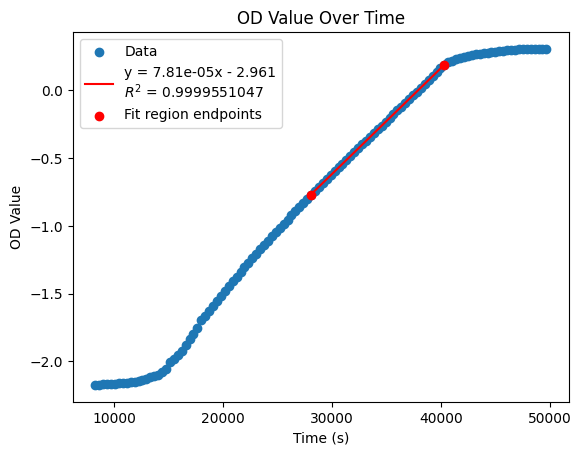

In [5]:
# plot shit

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(
    x_fit, y_fit,
    label=f"y = {m_best:.2e}x - {abs(b_best):.3f}\n$R^2$ = {r2_best:.10f}",
    color="red"
)
plt.scatter(
    [x_reg[0], x_reg[-1]],
    [y_reg[0], y_reg[-1]],
    color="red",
    zorder=5,
    label="Fit region endpoints"
)
plt.xlabel("Time (s)")
plt.ylabel("OD Value")
plt.title("OD Value Over Time")
plt.legend()
plt.show()